# Impact of $A$ on dipole + clustering map study

The goal of this notebook is to study the impact of A on the injected dipole measurement when a clustering effect is added.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import fitsio

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from mappers import CountMapper
from generators import Generator

In [2]:
##sources:
NSource_px_th = int(1e6)
#print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Theorical number of sources in one pixel : 1000000


## Importing clustering

/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with fewest chi samples.
  warnings_builtin.warn(*args, **kwargs)
/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


count    10000.000000
mean         0.000704
std          0.000298
min          0.000033
25%          0.000485
50%          0.000681
75%          0.000896
max          0.002026
Name: A, dtype: float64

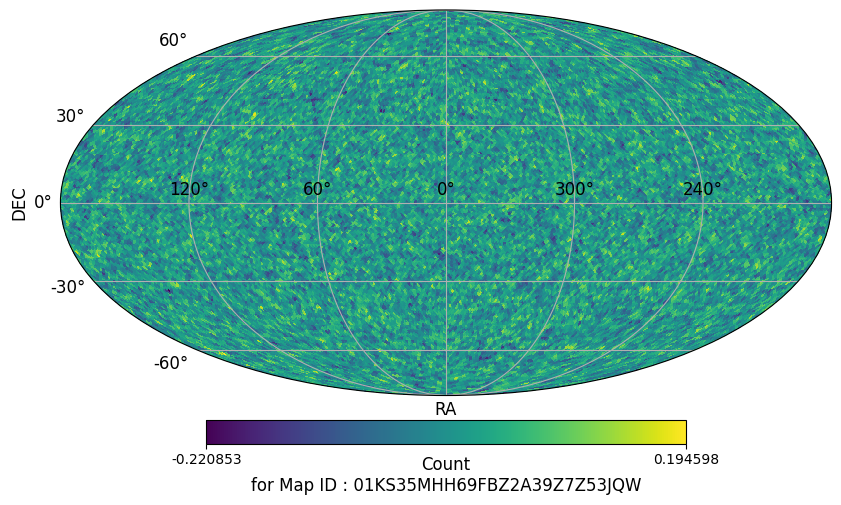

In [3]:
DIR = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "zmin0.1"
clFile = DIR + sufix + '.fits'

with fitsio.FITS(clFile, 'rw') as fits:
    dfNumpy = Table(fits['FIT_NUMPY'].read()).to_pandas()
    clMapper = CountMapper.from_map_fits(fits, idx=3, nest=False) #first clustering map
    clMapper = clMapper.invert_nest()
clMapper.plot()

generator = Generator(nside = clMapper.nside, nest = clMapper.nest)

clStats = dfNumpy.describe()
clStats['A']

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1872 (χ²/ndof = 0.0)       │              Nfcn = 324              │
│ EDM = 2.18e-05 (Goal: 0.0002)    │            time = 4.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  0.05e-3  │  1.59e-3  │  -0.05e-3  │  0.58e-3   │    0    │    1    │       │
│ 1 │ ra   │   0.015   │  280.569  │   -0.015   │  359.985   │    0    │   360   │       │
│ 2 │ dec  │    -10    │    120    │    -80     │    100     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.05e-3  │  0.58e-3  │  -0.015   │  359.985  │    -80    │    100    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │           A          ra         dec │
├─────┼─────────────────────────────────────┤
│   A │    3.26e-07  -163.52e-6 45.62478e-3 │
│  ra │  -163.52e-6         343      0.01e3 │
│ dec │ 45.62478e-3      0.01e3     2.6e+05 │
└─────┴─────────────────────────────────────┘

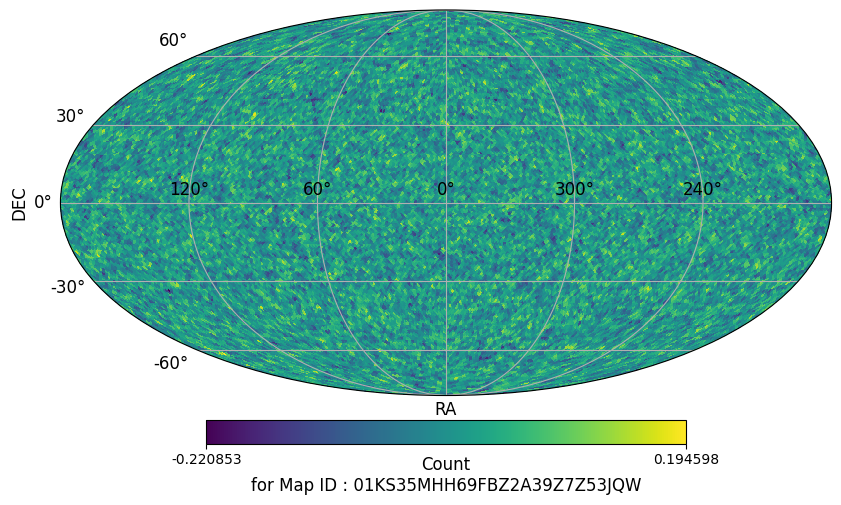

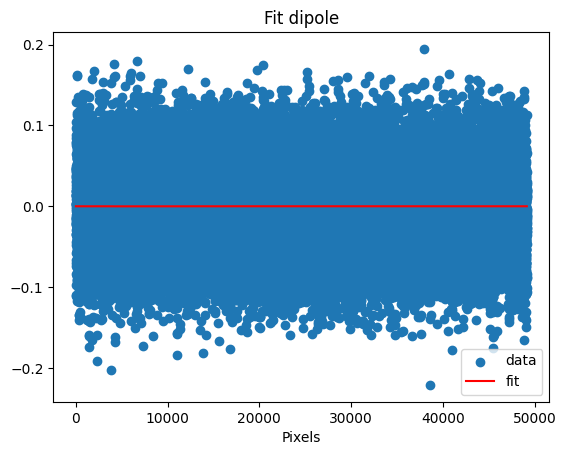

In [4]:
init =  (0, 100, 0)
clMapper.fit_dipole("", init, fit_monop=False)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 112.5 (χ²/ndof = 0.0)      │              Nfcn = 527              │
│ EDM = 5.72e-05 (Goal: 0.0002)    │            time = 7.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │   0.998   │   0.005   │   -0.005   │   0.005    │    0    │         │       │
│ 1 │ A    │  0.4e-3   │  32.1e-3  │  -0.4e-3   │   7.8e-3   │    0    │    1    │       │
│ 2 │ ra   │  0.06e-3  │349277.94e-3│  -0.06e-3  │359999.94e-3│    0    │   360   │       │
│ 3 │ dec  │    -40    │    110    │    -50     │    130     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.005   │   0.005   │  -0.4e-3  │  7.8e-3   │ -0.06e-3  │359999.94e-3│    -50    │    130    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────┐
│     │         N*          A         ra        dec │
├─────┼─────────────────────────────────────────────┤
│  N* │   2.03e-05         -0         -0  -0.135e-3 │
│   A │         -0   5.78e-05   -0.10e-3 -492.24e-3 │
│  ra │         -0   -0.10e-3       2.03      -14.4 │
│ dec │  -0.135e-3 -492.24e-3      -14.4   1.13e+06 │
└─────┴─────────────────────────────────────────────┘

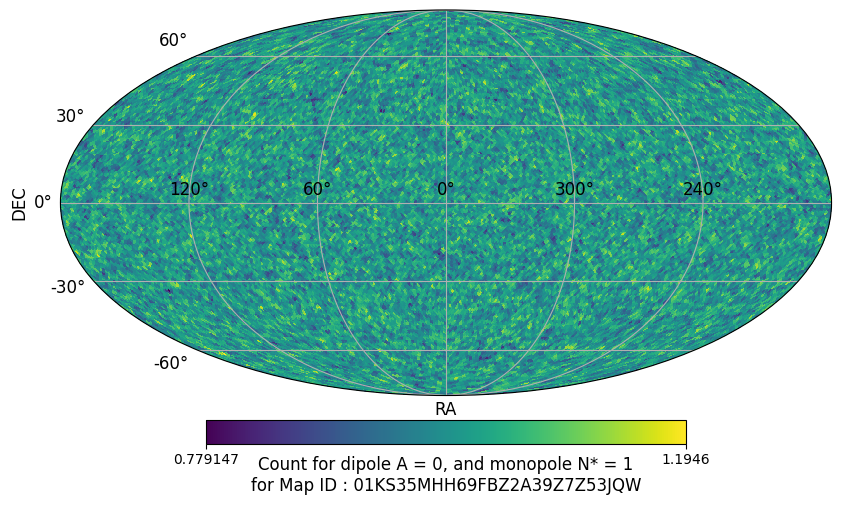

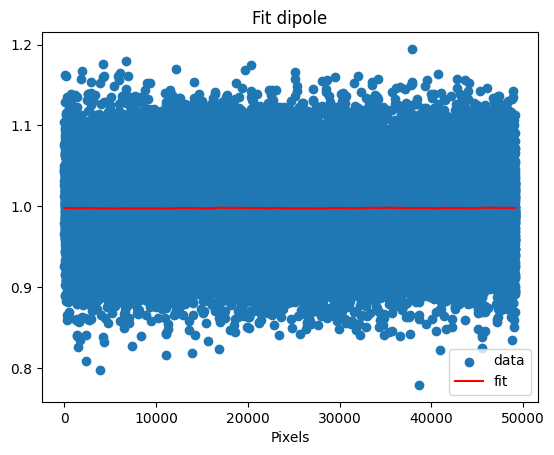

In [5]:
A, ra, dec = 0, 168, -7
M = 1
dipoleClMapper = generator.generate_dipoleContrast(A, ra, dec, clMapper=clMapper, unit = f"Clustering and dipole density contrast for A = {A}")
monopMapper = generator.generate_monopole(M, contrastMapper=dipoleClMapper, unit = f"Count for dipole A = {A}, and monopole N* = {M}")
init =  (1, 1, 100, 0)
monopMapper.fit_dipole("", init)

## Study with Poisson noise

In [6]:
DIR = "Fit_Clusters/Clusters_Dipole/Clusters_Dipole_"
suffix = "Param_study_Monop_poissVar"
outputfile = DIR + suffix +".fits"

data4 = fitsio.FITS(outputfile)
data4


  file: Fit_Clusters/Clusters_Dipole/Clusters_Dipole_Param_study_Monop_poissVar.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY_MAPS
  2      BINARY_TBL      A_STUDY
  3      BINARY_TBL      A_STUDY_densField

In [7]:
dfMinuit_data4 = Table(data4['A_STUDY'].read())
dfMinuit_data4['A-Acl'] = dfMinuit_data4['A'] - clStats['A']['mean']
dfMinuit_data4['A-Acl_err'] = np.sqrt(dfMinuit_data4['A_err']**2 + clStats['A']['std']**2)
dfMinuit_data4['A+Acl'] = dfMinuit_data4['A'] + clStats['A']['mean']
dfMinuit_data4['A+Acl_err'] = np.sqrt(dfMinuit_data4['A_err']**2 + clStats['A']['std']**2)
dfMinuit_data4 = dfMinuit_data4[dfMinuit_data4['valid']]

mask = dfMinuit_data4["N*_true"] == NSource_px_th
dfMinuit_filtered4 = dfMinuit_data4[mask]
mask_cl = dfMinuit_filtered4['Cluster_ID'] == clMapper.ID
dfMinuit_filtered4 = dfMinuit_filtered4[mask_cl]
dfMinuit_filtered4

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,N*_true,A_true,ra_true,dec_true,Cluster_ID,A-Acl,A-Acl_err,A+Acl,A+Acl_err
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,int64,float64,int64,int64,str26,float64,float64,float64,float64
01KWEDCPY9N6336NH850YTBB81,997774.068148524,1.0,4.505524446605705,False,0.0,inf,0.0009080459916566082,1.0,7.826124660612348e-06,False,0.0,1.0,210.48955489471223,100.0,0.5497944299351616,False,0.0,360.0,-26.104775171808594,0.0,0.49367808723173745,False,-90.0,90.0,True,1000000,0.001,168,-7,01KS35MHH69FBZ2A39Z7Z53JQW,0.00020370327909535377,0.00029764668792141687,0.0016123887042178626,0.00029764668792141687
01KWEDCWQB9KWG8WYMM3VZJMH4,997776.9284845376,1.0,4.505535349715501,False,0.0,inf,0.0009917530321822392,1.0,7.825508965662083e-06,False,0.0,1.0,205.6316377584451,100.0,0.4978742040217128,False,0.0,360.0,-24.786438880558066,0.0,0.45196557037582785,False,-90.0,90.0,True,1000000,0.0010985411419875584,168,-7,01KS35MHH69FBZ2A39Z7Z53JQW,0.00028741031962098483,0.00029764667173337844,0.0016960957447434938,0.00029764667173337844
01KWEDD1D95MW5XJ8GY3WFZCQB,997775.4838791254,1.0,4.505529630347155,False,0.0,inf,0.0010688959195166033,1.0,7.822823755327182e-06,False,0.0,1.0,201.7550532586131,100.0,0.45800440087515426,False,0.0,360.0,-23.756438464309692,0.0,0.4191332505599412,False,-90.0,90.0,True,1000000,0.0012067926406393288,168,-7,01KS35MHH69FBZ2A39Z7Z53JQW,0.0003645532069553489,0.0002976466011478928,0.0017732386320778578,0.0002976466011478928
01KWEDD5XSR241MC668PE801QV,997777.883102457,1.0,4.505537453806028,False,0.0,inf,0.0011837049107487614,1.0,7.822994448069783e-06,False,0.0,1.0,198.65758277998202,100.0,0.4101871111018198,False,0.0,360.0,-22.65897543300261,0.0,0.378457643644202,False,-90.0,90.0,True,1000000,0.0013257113655901094,168,-7,01KS35MHH69FBZ2A39Z7Z53JQW,0.000479362198187507,0.00029764660563413186,0.001888047623310016,0.00029764660563413186
01KWEDDAVTYY13X6GKXC9C63W7,997776.9009826519,1.0,4.505533018964343,False,0.0,inf,0.001288184158123539,1.0,7.82255589071594e-06,False,0.0,1.0,194.4812065871555,100.0,0.3725143507540736,False,0.0,360.0,-20.96379196950391,0.0,0.3477990725561142,False,-90.0,90.0,True,1000000,0.0014563484775012444,168,-7,01KS35MHH69FBZ2A39Z7Z53JQW,0.0005838414455622845,0.00029764659410792734,0.0019925268706847935,0.00029764659410792734
01KWEDDFMDPNBZYV5ES1GP4PB8,997771.0842019852,1.0,4.505524815176614,False,0.0,inf,0.0014089521659147784,1.0,7.822801835031092e-06,False,0.0,1.0,192.5049352908213,100.0,0.33986691950609327,False,0.0,360.0,-20.653093404046608,0.0,0.31796901131626676,False,-90.0,90.0,True,1000000,0.0015998587196060573,168,-7,01KS35MHH69FBZ2A39Z7Z53JQW,0.000704609453353524,0.0002976466005717788,0.0021132948784760327,0.0002976466005717788
01KWEDDM2MRM1VKNRV9AFTEV7J,997776.376910484,1.0,4.505524631822482,False,0.0,inf,0.0015653770482825912,1.0,7.822379618227038e-06,False,0.0,1.0,189.65047094493798,100.0,0.3029974993876152,False,0.0,360.0,-19.126704261274877,0.0,0.28621725496642725,False,-90.0,90.0,True,1000000,0.0017575106248547913,168,-7,01KS35MHH69FBZ2A39Z7Z53JQW,0.0008610343357213368,0.0002976465894752996,0.0022697197608438457,0.0002976465894752996
01KWEDDRGJFDWDPA1V4VA6K37R,997769.632808341,1.0,4.505515250959434,False,0.0,inf,0.0017198899024253318,1.0,7.822466912661198e-06,False,0.0,1.0,187.4372907027873,100.0,0.27423202332765584,False,0.0,360.0,-18.180052389064496,0.0,0.2604976443391358,False,-90.0,90.0,True,1000000,0.0019306977288832496,168,-7,01KS35MHH69FBZ2A39Z7Z53JQW,0.0010155471898640775,0.0002976465917694768,0.002424232614986586,0.0002976465917694768
01KWEDDX8KV7772H7MY9XTME6Q,997778.3822289321,1.0,4.505535349831916,False,0.0,inf,0.001899227850946035,1.0,7.8230919244

Saving Cluster_A_study_valAcorr_PoissVar in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_valAcorr_PoissVar.pdf


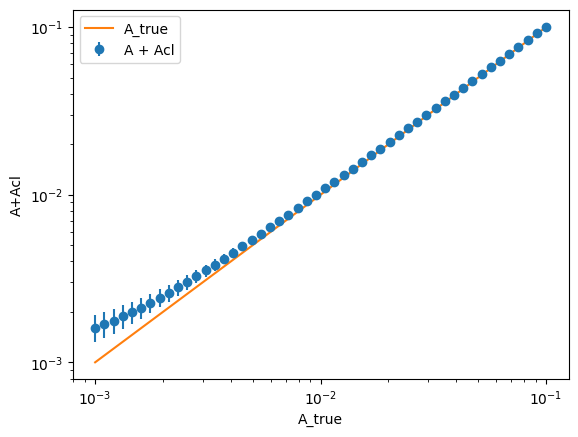

In [8]:
compareFit_val(dfMinuit_filtered4, "A", "A+Acl", ytrue = "A_true", nsigma=1, surface=False, yscale='log', label_true="A_true", label_fit="A + Acl")

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/"
sufix = "Cluster_A_study_valAcorr_PoissVar"
get_savefig(plt, output_path, sufix)

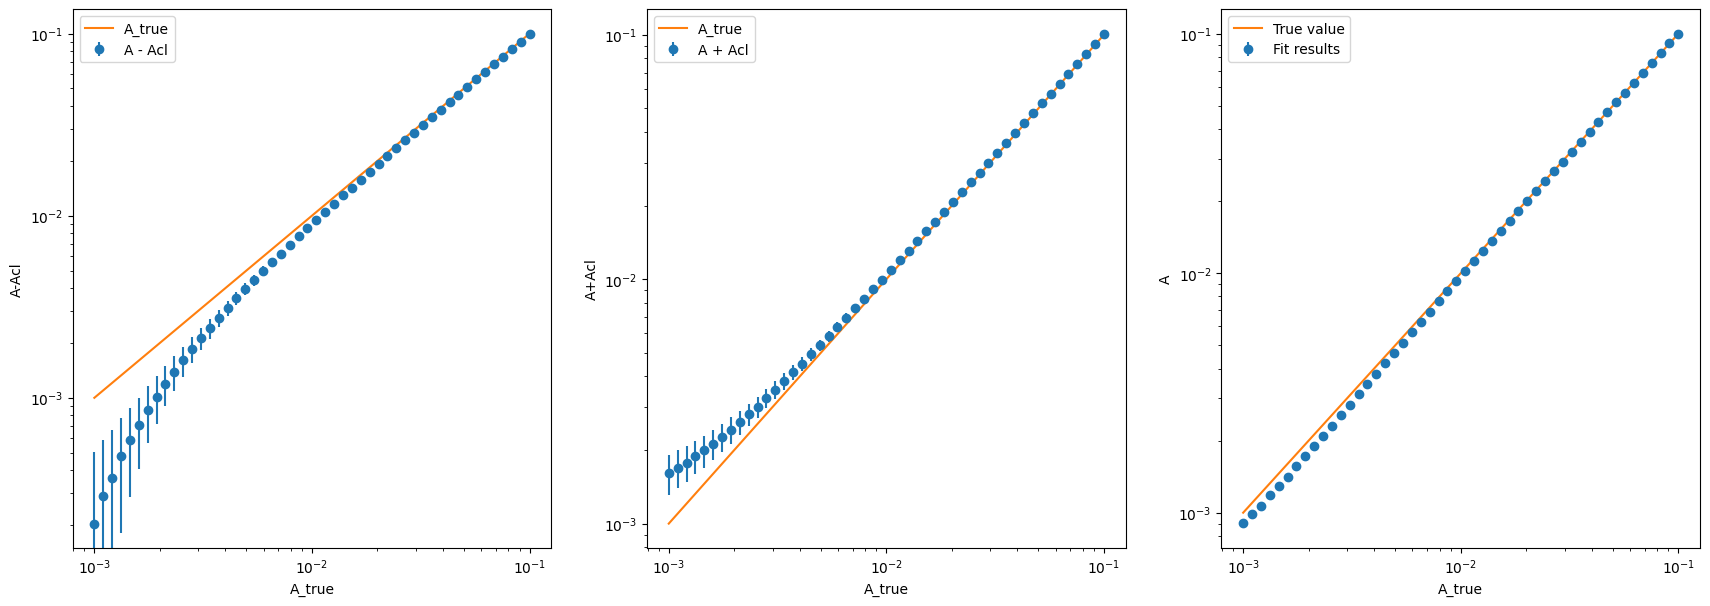

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_val(dfMinuit_filtered4, "A", "A-Acl", ytrue = "A_true", nsigma=1, surface=False, yscale='log', label_true="A_true", label_fit="A - Acl", figax=(fig, ax[0]))
compareFit_val(dfMinuit_filtered4, "A", "A+Acl", ytrue = "A_true", nsigma=1, surface=False, yscale='log', label_true="A_true", label_fit="A + Acl", figax=(fig, ax[1]))
compareFit_val(dfMinuit_filtered4, "A", "A", nsigma=1, surface=False, yscale='log', figax=(fig, ax[2]))

Saving Cluster_A_study_valARaDec_withN1e6_PoissVar in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_valARaDec_withN1e6_PoissVar.pdf


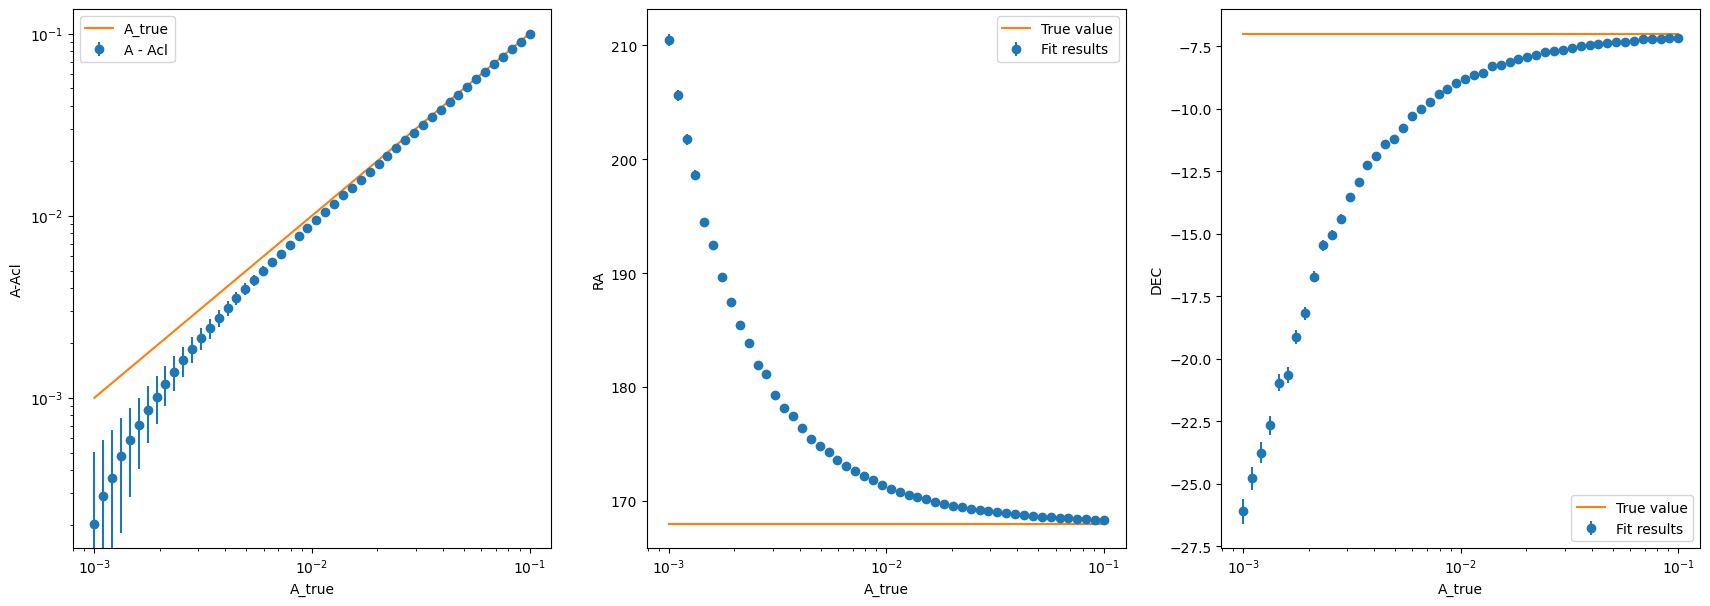

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_val(dfMinuit_filtered4, "A", "A-Acl", ytrue = "A_true", nsigma=1, surface=False, yscale='log', label_true="A_true", label_fit="A - Acl", figax=(fig, ax[0]))
compareFit_val(dfMinuit_filtered4, "A", "ra", ylabel = "RA", nsigma=1, surface=False, figax=(fig, ax[1]))
compareFit_val(dfMinuit_filtered4, "A", "dec", ylabel = "DEC", nsigma=1, surface=False, figax=(fig, ax[2]))

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/"
sufix = "Cluster_A_study_valARaDec_withN1e6_PoissVar"
get_savefig(plt, output_path, sufix)

Saving Cluster_A_study_ratioARaDec_withN1e6_PoissVar in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_ratioARaDec_withN1e6_PoissVar.pdf


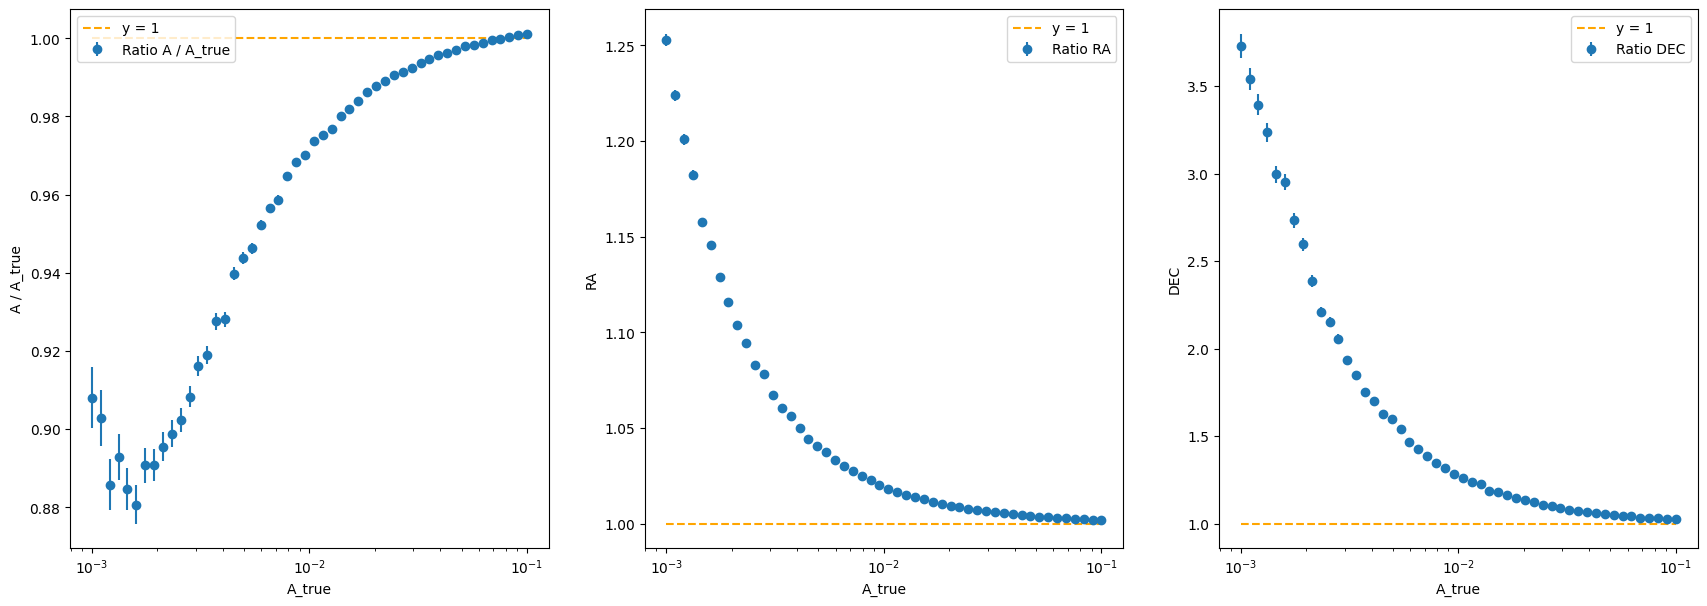

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered4, "A", "A", nsigma=1, figax=(fig, ax[0]), surface=False)
compareFit_ratio(dfMinuit_filtered4, "A", "ra", ylabel="RA", nsigma=5, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered4, "A", "dec", ylabel="DEC", nsigma=5, figax=(fig, ax[2]), surface=False)

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/"
sufix = "Cluster_A_study_ratioARaDec_withN1e6_PoissVar"
get_savefig(plt, output_path, sufix)

## Histogramm study

In [12]:
dfMinuit_data4['A_true']

0.001
0.0010985411419875584
0.0012067926406393288
0.0013257113655901094
0.0014563484775012444
0.0015998587196060573
0.0017575106248547913
0.0019306977288832496
0.0021209508879201904
0.002329951810515372
0.002559547922699536


### For a given $A_{true}$

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 21.55 (χ²/ndof = 0.7)      │              Nfcn = 286              │
│ EDM = 9.15e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Agauss │  4.9e-3   │  0.6e-3   │  -0.6e-3   │   0.6e-3   │         │         │       │
│ 1 │ mu     │  0.22e-3  │  0.06e-3  │  -0.06e-3  │  0.07e-3   │         │         │       │
│ 2 │ sigma  │  0.48e-3  │  0.09e-3  │  -0.08e-3  │  0.11e-3   │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │        Agauss         │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.6e-3  │  0.6e-3   │ -0.06e-3  │  0.07e-3  │ -0.08e-3  │  0.11e-3  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────────┬────────────────────────────┐
│        │   Agauss       mu    sigma │
├────────┼────────────────────────────┤
│ Agauss │ 3.56e-07     3e-9    20e-9 │
│     mu │     3e-9 3.92e-09     1e-9 │
│  sigma │    20e-9     1e-9 7.98e-09 │
└────────┴────────────────────────────┘

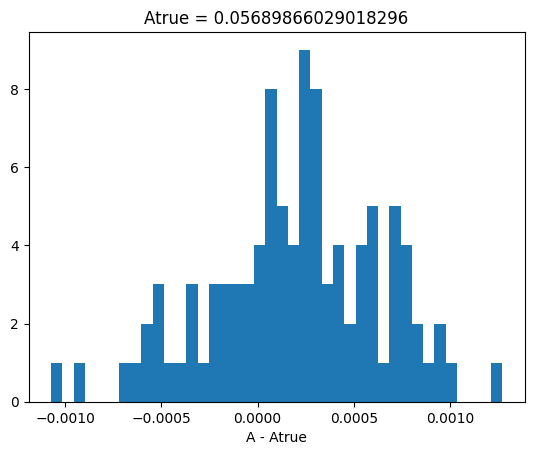

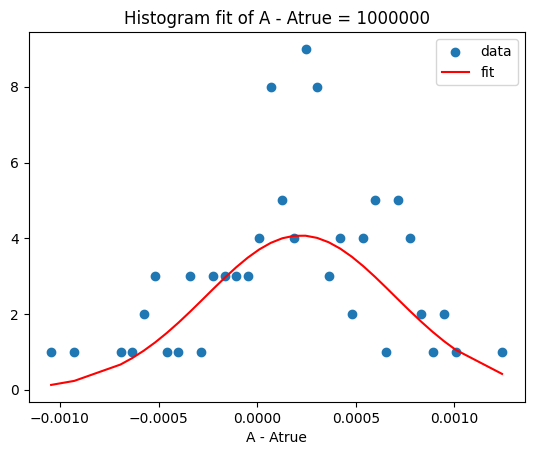

In [48]:
Atrue = 0.05689866029018296
mask = dfMinuit_data4['A_true'] == Atrue
dfMinuit_filtered_Atrue = dfMinuit_data4[mask]

var, bins = get_hist(dfMinuit_filtered_Atrue['A'] - Atrue, bins=40, xlabel="A - Atrue", title=f"Atrue = {Atrue}")
mask2 = var != 0

m = fit_minuit(bins[mask2], var[mask2], np.sqrt(var[mask2]), gauss, (1e-2, 0, 5e-4), ("Agauss", "mu", "sigma"),
              title="Histogram fit of A - Atrue = {}".format(NSource_px_th), xlabel="A - Atrue")
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 24.38 (χ²/ndof = 0.9)      │              Nfcn = 348              │
│ EDM = 8.98e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Agauss │  5.3e-3   │  0.8e-3   │  -0.7e-3   │   0.8e-3   │         │         │       │
│ 1 │ mu     │  0.09e-3  │  0.08e-3  │  -0.08e-3  │  0.09e-3   │         │         │       │
│ 2 │ sigma  │  0.54e-3  │  0.12e-3  │  -0.11e-3  │  0.15e-3   │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │        Agauss         │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.7e-3  │  0.8e-3   │ -0.08e-3  │  0.09e-3  │ -0.11e-3  │  0.15e-3  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────────┬────────────────────────────┐
│        │   Agauss       mu    sigma │
├────────┼────────────────────────────┤
│ Agauss │ 6.06e-07    15e-9 0.058e-6 │
│     mu │    15e-9 6.66e-09     2e-9 │
│  sigma │ 0.058e-6     2e-9 1.51e-08 │
└────────┴────────────────────────────┘

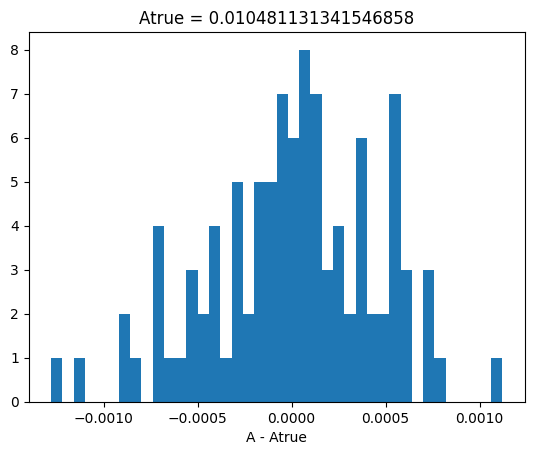

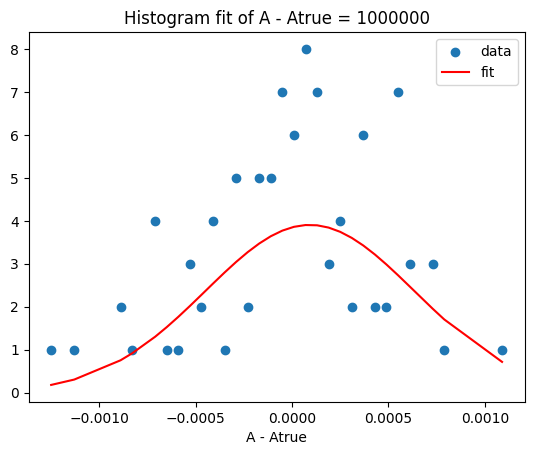

In [49]:
Atrue = 0.010481131341546858
mask = dfMinuit_data4['A_true'] == Atrue
dfMinuit_filtered_Atrue = dfMinuit_data4[mask]

var, bins = get_hist(dfMinuit_filtered_Atrue['A'] - Atrue, bins=40, xlabel="A - Atrue", title=f"Atrue = {Atrue}")
mask2 = var != 0

m = fit_minuit(bins[mask2], var[mask2], np.sqrt(var[mask2]), gauss, (1e-2, 0, 5e-4), ("Agauss", "mu", "sigma"),
              title="Histogram fit of A - Atrue = {}".format(NSource_px_th), xlabel="A - Atrue")
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 13.12 (χ²/ndof = 0.5)      │              Nfcn = 326              │
│ EDM = 1.92e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Agauss │  6.4e-3   │  0.9e-3   │  -0.9e-3   │   1.0e-3   │         │         │       │
│ 1 │ mu     │  0.10e-3  │  0.08e-3  │  -0.08e-3  │  0.09e-3   │         │         │       │
│ 2 │ sigma  │  0.55e-3  │  0.11e-3  │  -0.10e-3  │  0.13e-3   │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │        Agauss         │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.9e-3  │  1.0e-3   │ -0.08e-3  │  0.09e-3  │ -0.10e-3  │  0.13e-3  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────────┬────────────────────────────┐
│        │   Agauss       mu    sigma │
├────────┼────────────────────────────┤
│ Agauss │ 8.04e-07    24e-9 0.063e-6 │
│     mu │    24e-9 7.01e-09     4e-9 │
│  sigma │ 0.063e-6     4e-9 1.22e-08 │
└────────┴────────────────────────────┘

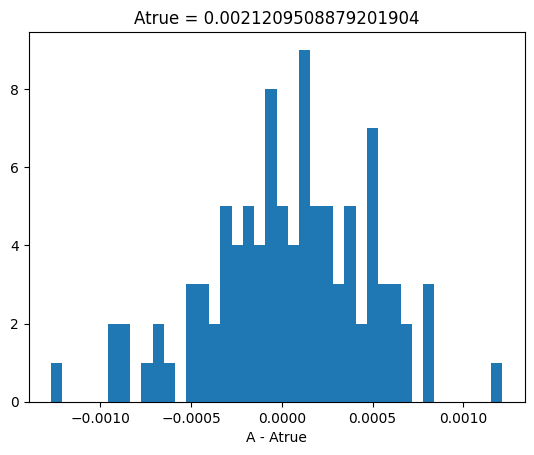

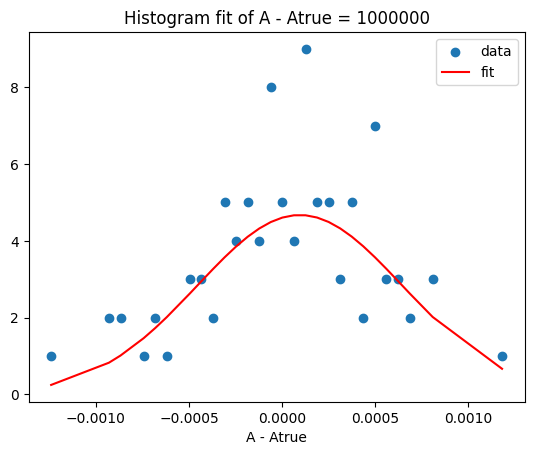

In [50]:
Atrue = 0.0021209508879201904
mask = dfMinuit_data4['A_true'] == Atrue
dfMinuit_filtered_Atrue = dfMinuit_data4[mask]

var, bins = get_hist(dfMinuit_filtered_Atrue['A'] - Atrue, bins=40, xlabel="A - Atrue", title=f"Atrue = {Atrue}")
mask2 = var != 0

m = fit_minuit(bins[mask2], var[mask2], np.sqrt(var[mask2]), gauss, (1e-2, 0, 5e-4), ("Agauss", "mu", "sigma"),
              title="Histogram fit of A - Atrue = {}".format(NSource_px_th), xlabel="A - Atrue")
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 12.32 (χ²/ndof = 0.4)      │              Nfcn = 338              │
│ EDM = 5.42e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Agauss │  5.1e-3   │  0.7e-3   │  -0.7e-3   │   0.8e-3   │         │         │       │
│ 1 │ mu     │  0.18e-3  │  0.08e-3  │  -0.08e-3  │  0.09e-3   │         │         │       │
│ 2 │ sigma  │  0.52e-3  │  0.10e-3  │  -0.09e-3  │  0.12e-3   │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │        Agauss         │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.7e-3  │  0.8e-3   │ -0.08e-3  │  0.09e-3  │ -0.09e-3  │  0.12e-3  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────────┬────────────────────────────┐
│        │   Agauss       mu    sigma │
├────────┼────────────────────────────┤
│ Agauss │ 4.95e-07    13e-9    41e-9 │
│     mu │    13e-9 6.14e-09     2e-9 │
│  sigma │    41e-9     2e-9 9.94e-09 │
└────────┴────────────────────────────┘

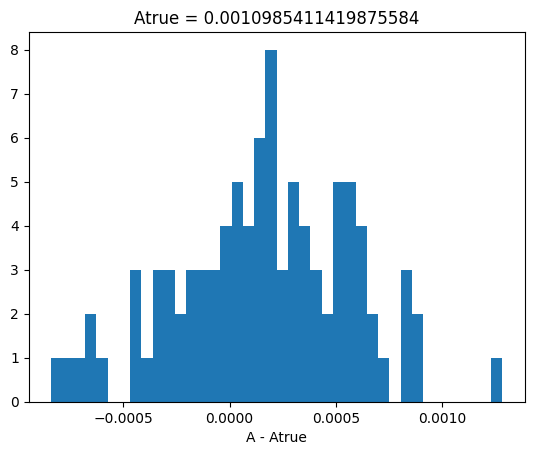

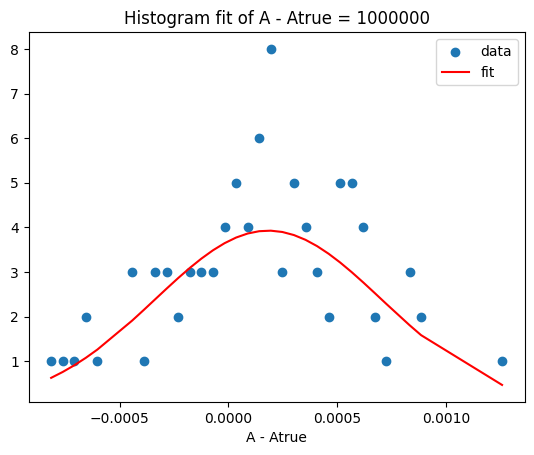

In [51]:
Atrue = 0.0010985411419875584
mask = dfMinuit_data4['A_true'] == Atrue
dfMinuit_filtered_Atrue = dfMinuit_data4[mask]

var, bins = get_hist(dfMinuit_filtered_Atrue['A'] - Atrue, bins=40, xlabel="A - Atrue", title=f"Atrue = {Atrue}")
mask2 = var != 0

m = fit_minuit(bins[mask2], var[mask2], np.sqrt(var[mask2]), gauss, (1e-2, 0, 5e-4), ("Agauss", "mu", "sigma"),
              title="Histogram fit of A - Atrue = {}".format(NSource_px_th), xlabel="A - Atrue")
m

### For a range of $A_{true}$

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 17.79 (χ²/ndof = 0.6)      │              Nfcn = 207              │
│ EDM = 3.55e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Agauss │  0.0162   │  0.0012   │  -0.0012   │   0.0012   │         │         │       │
│ 1 │ mu     │  0.03e-3  │  0.06e-3  │  -0.06e-3  │  0.06e-3   │         │         │       │
│ 2 │ sigma  │  0.73e-3  │  0.06e-3  │  -0.06e-3  │  0.06e-3   │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │        Agauss         │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.0012  │  0.0012   │ -0.06e-3  │  0.06e-3  │ -0.06e-3  │  0.06e-3  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────────┬────────────────────────────┐
│        │   Agauss       mu    sigma │
├────────┼────────────────────────────┤
│ Agauss │ 1.53e-06     0e-9  18.0e-9 │
│     mu │     0e-9 3.86e-09  -0.2e-9 │
│  sigma │  18.0e-9  -0.2e-9 3.41e-09 │
└────────┴────────────────────────────┘

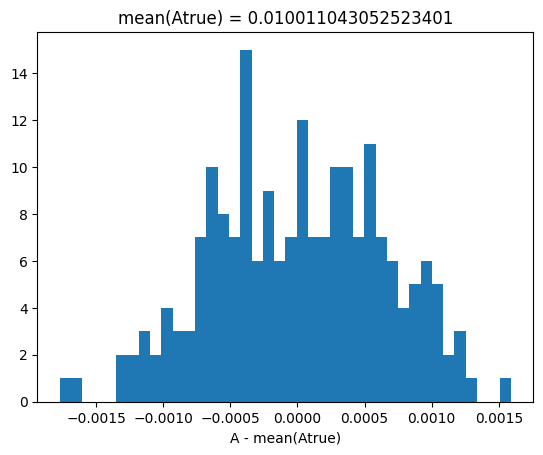

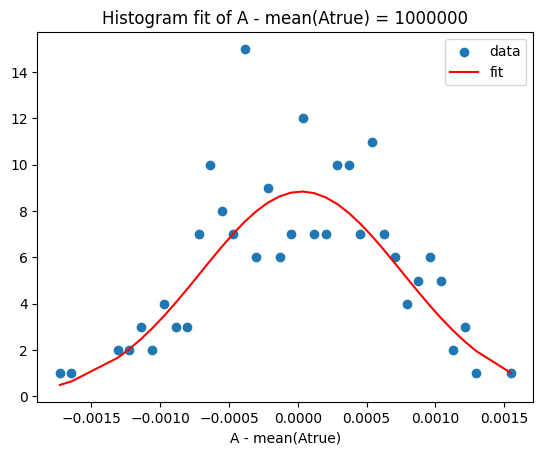

In [52]:
mask = (dfMinuit_data4['A_true'] >= 0.9e-2) & (dfMinuit_data4['A_true'] < 1.1e-2)
dfMinuit_filtered_Atrue = dfMinuit_data4[mask]
Atrue = dfMinuit_filtered_Atrue['A_true'].mean()

var, bins = get_hist(dfMinuit_filtered_Atrue['A'] - Atrue, bins=40, xlabel="A - mean(Atrue)", title=f"mean(Atrue) = {Atrue}")
mask2 = var != 0

m = fit_minuit(bins[mask2], var[mask2], np.sqrt(var[mask2]), gauss, (1e-2, 0, 5e-4), ("Agauss", "mu", "sigma"),
              title="Histogram fit of A - mean(Atrue) = {}".format(NSource_px_th), xlabel="A - mean(Atrue)")
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 24.38 (χ²/ndof = 0.9)      │              Nfcn = 348              │
│ EDM = 8.98e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Agauss │  5.3e-3   │  0.8e-3   │  -0.7e-3   │   0.8e-3   │         │         │       │
│ 1 │ mu     │  0.09e-3  │  0.08e-3  │  -0.08e-3  │  0.09e-3   │         │         │       │
│ 2 │ sigma  │  0.54e-3  │  0.12e-3  │  -0.11e-3  │  0.15e-3   │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │        Agauss         │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.7e-3  │  0.8e-3   │ -0.08e-3  │  0.09e-3  │ -0.11e-3  │  0.15e-3  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────────┬────────────────────────────┐
│        │   Agauss       mu    sigma │
├────────┼────────────────────────────┤
│ Agauss │ 6.06e-07    15e-9 0.058e-6 │
│     mu │    15e-9 6.66e-09     2e-9 │
│  sigma │ 0.058e-6     2e-9 1.51e-08 │
└────────┴────────────────────────────┘

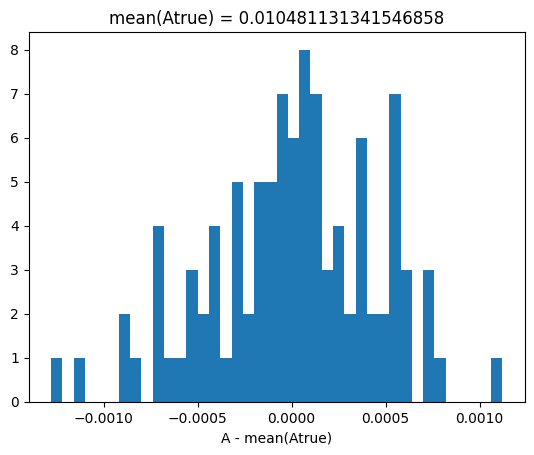

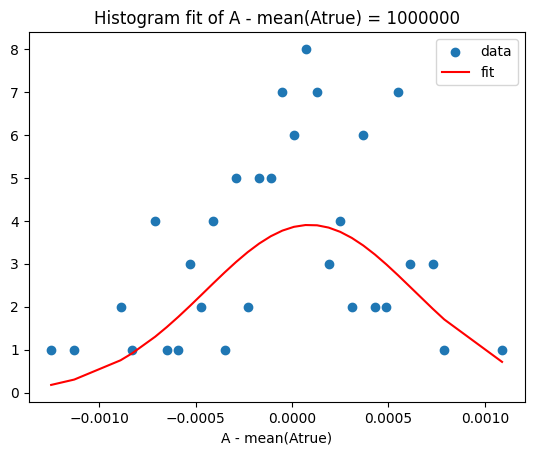

In [71]:
mask = (dfMinuit_data4['A_true'] >= 1.0e-2) & (dfMinuit_data4['A_true'] < 1.1e-2)
dfMinuit_filtered_Atrue = dfMinuit_data4[mask]
Atrue = dfMinuit_filtered_Atrue['A_true'].mean()

var, bins = get_hist(dfMinuit_filtered_Atrue['A'] - Atrue, bins=40, xlabel="A - mean(Atrue)", title=f"mean(Atrue) = {Atrue}")
mask2 = var != 0

m = fit_minuit(bins[mask2], var[mask2], np.sqrt(var[mask2]), gauss, (1e-2, 0, 5e-4), ("Agauss", "mu", "sigma"),
              title="Histogram fit of A - mean(Atrue) = {}".format(NSource_px_th), xlabel="A - mean(Atrue)")
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 23.36 (χ²/ndof = 0.8)      │              Nfcn = 336              │
│ EDM = 3.55e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Agauss │  5.0e-3   │  0.7e-3   │  -0.6e-3   │   0.7e-3   │         │         │       │
│ 1 │ mu     │  0.02e-3  │  0.07e-3  │  -0.07e-3  │  0.08e-3   │         │         │       │
│ 2 │ sigma  │  0.51e-3  │  0.10e-3  │  -0.09e-3  │  0.13e-3   │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │        Agauss         │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.6e-3  │  0.7e-3   │ -0.07e-3  │  0.08e-3  │ -0.09e-3  │  0.13e-3  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────────┬────────────────────────────┐
│        │   Agauss       mu    sigma │
├────────┼────────────────────────────┤
│ Agauss │ 4.26e-07     7e-9 0.033e-6 │
│     mu │     7e-9 5.09e-09     2e-9 │
│  sigma │ 0.033e-6     2e-9  1.1e-08 │
└────────┴────────────────────────────┘

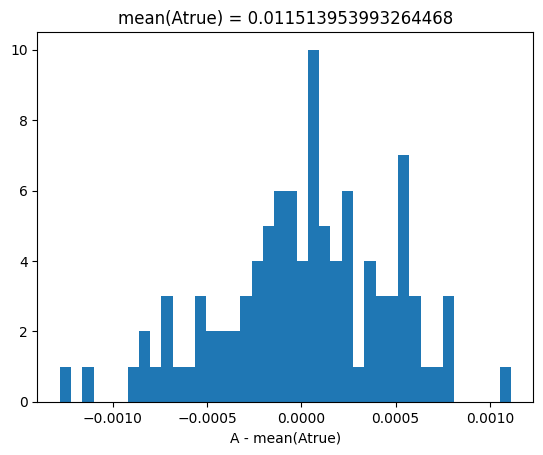

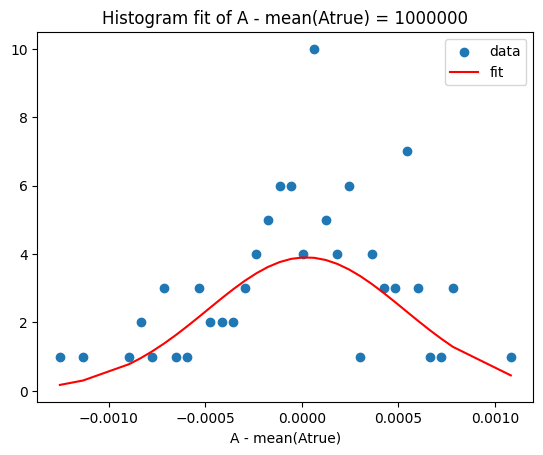

In [70]:
mask = (dfMinuit_data4['A_true'] >= 1.1e-2) & (dfMinuit_data4['A_true'] < 1.2e-2)
dfMinuit_filtered_Atrue = dfMinuit_data4[mask]
Atrue = dfMinuit_filtered_Atrue['A_true'].mean()

var, bins = get_hist(dfMinuit_filtered_Atrue['A'] - Atrue, bins=40, xlabel="A - mean(Atrue)", title=f"mean(Atrue) = {Atrue}")
mask2 = var != 0

m = fit_minuit(bins[mask2], var[mask2], np.sqrt(var[mask2]), gauss, (1e-2, 0, 5e-4), ("Agauss", "mu", "sigma"),
              title="Histogram fit of A - mean(Atrue) = {}".format(NSource_px_th), xlabel="A - mean(Atrue)")
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 16.82 (χ²/ndof = 0.6)      │              Nfcn = 303              │
│ EDM = 2.41e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Agauss │  5.3e-3   │  0.6e-3   │  -0.6e-3   │   0.6e-3   │         │         │       │
│ 1 │ mu     │  0.15e-3  │  0.06e-3  │  -0.06e-3  │  0.06e-3   │         │         │       │
│ 2 │ sigma  │  0.48e-3  │  0.08e-3  │  -0.07e-3  │  0.09e-3   │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │        Agauss         │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.6e-3  │  0.6e-3   │ -0.06e-3  │  0.06e-3  │ -0.07e-3  │  0.09e-3  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────────┬────────────────────────────┐
│        │   Agauss       mu    sigma │
├────────┼────────────────────────────┤
│ Agauss │ 3.85e-07     3e-9    18e-9 │
│     mu │     3e-9 3.75e-09     0e-9 │
│  sigma │    18e-9     0e-9 6.37e-09 │
└────────┴────────────────────────────┘

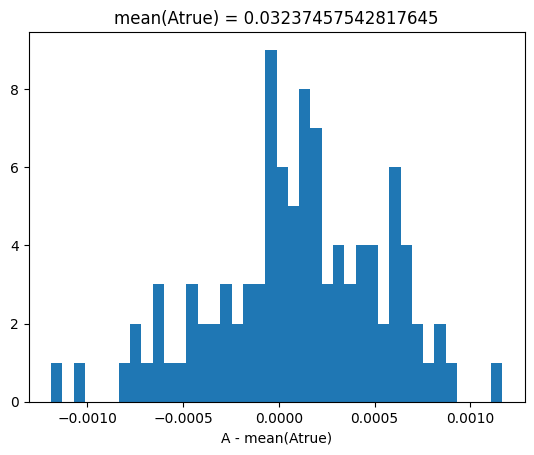

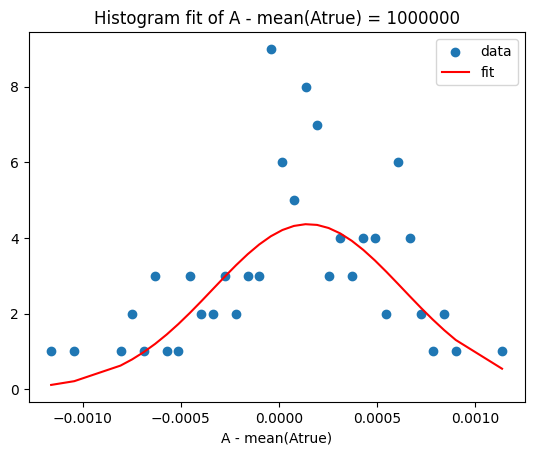

In [67]:
mask = (dfMinuit_data4['A_true'] >= 3.2e-2) & (dfMinuit_data4['A_true'] < 3.3e-2)
dfMinuit_filtered_Atrue = dfMinuit_data4[mask]
Atrue = dfMinuit_filtered_Atrue['A_true'].mean()

var, bins = get_hist(dfMinuit_filtered_Atrue['A'] - Atrue, bins=40, xlabel="A - mean(Atrue)", title=f"mean(Atrue) = {Atrue}")
mask2 = var != 0

m = fit_minuit(bins[mask2], var[mask2], np.sqrt(var[mask2]), gauss, (1e-2, 0, 5e-4), ("Agauss", "mu", "sigma"),
              title="Histogram fit of A - mean(Atrue) = {}".format(NSource_px_th), xlabel="A - mean(Atrue)")
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 17.34 (χ²/ndof = 0.6)      │              Nfcn = 328              │
│ EDM = 1.98e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Agauss │  5.4e-3   │  0.7e-3   │  -0.7e-3   │   0.7e-3   │         │         │       │
│ 1 │ mu     │  0.21e-3  │  0.07e-3  │  -0.08e-3  │  0.07e-3   │         │         │       │
│ 2 │ sigma  │  0.53e-3  │  0.11e-3  │  -0.09e-3  │  0.13e-3   │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │        Agauss         │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.7e-3  │  0.7e-3   │ -0.08e-3  │  0.07e-3  │ -0.09e-3  │  0.13e-3  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────────┬────────────────────────────┐
│        │   Agauss       mu    sigma │
├────────┼────────────────────────────┤
│ Agauss │ 4.75e-07    -2e-9 0.038e-6 │
│     mu │    -2e-9 5.13e-09    -1e-9 │
│  sigma │ 0.038e-6    -1e-9 1.13e-08 │
└────────┴────────────────────────────┘

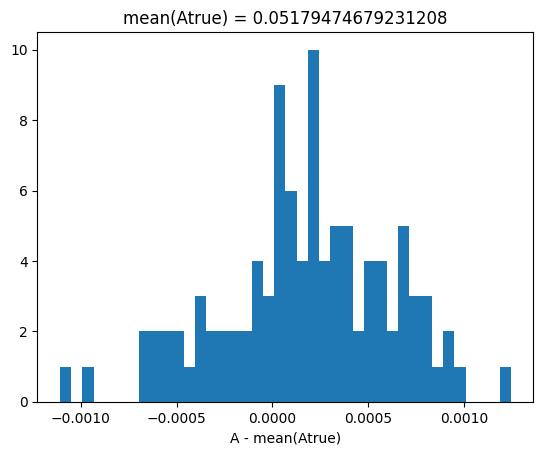

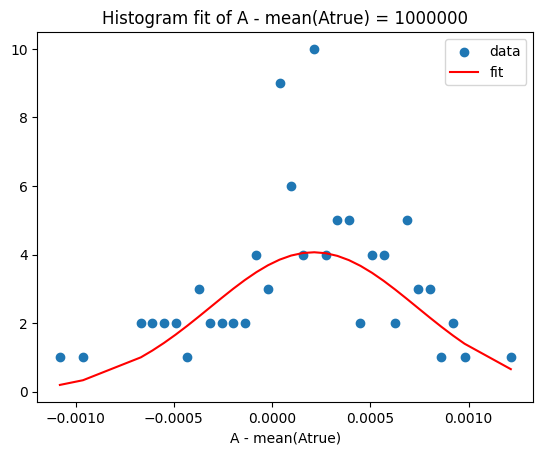

In [68]:
mask = (dfMinuit_data4['A_true'] >= 5.1e-2) & (dfMinuit_data4['A_true'] < 5.2e-2)
dfMinuit_filtered_Atrue = dfMinuit_data4[mask]
Atrue = dfMinuit_filtered_Atrue['A_true'].mean()

var, bins = get_hist(dfMinuit_filtered_Atrue['A'] - Atrue, bins=40, xlabel="A - mean(Atrue)", title=f"mean(Atrue) = {Atrue}")
mask2 = var != 0

m = fit_minuit(bins[mask2], var[mask2], np.sqrt(var[mask2]), gauss, (1e-2, 0, 5e-4), ("Agauss", "mu", "sigma"),
              title="Histogram fit of A - mean(Atrue) = {}".format(NSource_px_th), xlabel="A - mean(Atrue)")
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 12.09 (χ²/ndof = 0.4)      │              Nfcn = 305              │
│ EDM = 8.66e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Agauss │  5.4e-3   │  0.7e-3   │  -0.6e-3   │   0.7e-3   │         │         │       │
│ 1 │ mu     │  0.45e-3  │  0.07e-3  │  -0.07e-3  │  0.07e-3   │         │         │       │
│ 2 │ sigma  │  0.51e-3  │  0.09e-3  │  -0.08e-3  │  0.11e-3   │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │        Agauss         │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.6e-3  │  0.7e-3   │ -0.07e-3  │  0.07e-3  │ -0.08e-3  │  0.11e-3  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────────┬────────────────────────────┐
│        │   Agauss       mu    sigma │
├────────┼────────────────────────────┤
│ Agauss │ 4.42e-07     5e-9    27e-9 │
│     mu │     5e-9  4.5e-09     1e-9 │
│  sigma │    27e-9     1e-9 8.01e-09 │
└────────┴────────────────────────────┘

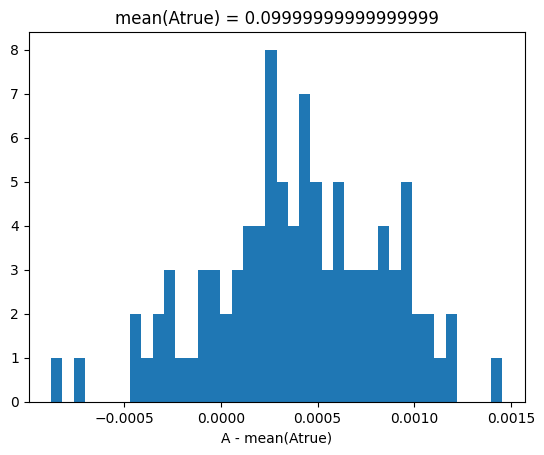

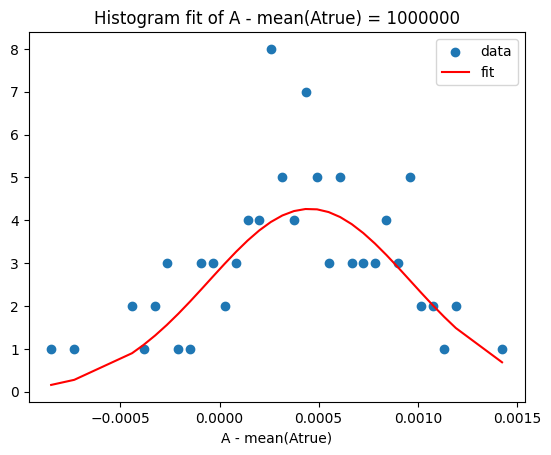

In [57]:
mask = (dfMinuit_data4['A_true'] >= 0.99e-1) & (dfMinuit_data4['A_true'] < 1.1e-1)
dfMinuit_filtered_Atrue = dfMinuit_data4[mask]
Atrue = dfMinuit_filtered_Atrue['A_true'].mean()

var, bins = get_hist(dfMinuit_filtered_Atrue['A'] - Atrue, bins=40, xlabel="A - mean(Atrue)", title=f"mean(Atrue) = {Atrue}")
mask2 = var != 0

m = fit_minuit(bins[mask2], var[mask2], np.sqrt(var[mask2]), gauss, (1e-2, 0, 5e-4), ("Agauss", "mu", "sigma"),
              title="Histogram fit of A - mean(Atrue) = {}".format(NSource_px_th), xlabel="A - mean(Atrue)")
m

## With $N^*$ fixed

In [12]:
dfMinuit_data4_dens = Table(data4['A_STUDY_densField'].read())
mask = dfMinuit_data4_dens["N*_fixed"] == True
dfMinuit_filtered4_densMonopFixed = dfMinuit_data4_dens[mask]
dfMinuit_filtered4_densMonopFixed

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,N*_true,A_true,ra_true,dec_true,Cluster_ID
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,int64,float64,int64,int64,str26
01KT3QFZZHN10T2CCQSN6K7FTS,1.0,1.0,0.01,True,0.0,inf,0.0001504216808546215,1.0,0.08010806823839045,False,0.0,1.0,353.1161794000958,100.0,280.1672724743731,False,0.0,360.0,81.82841394410862,0.0,132.3902544343969,False,-90.0,90.0,True,1,0.001,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QG7763SY4ZMZTHATS8R62,1.0,1.0,0.01,True,0.0,inf,1.2532158298013201e-06,1.0,0.02612042270028017,False,0.0,1.0,356.4027199581255,100.0,288.6285829281286,False,0.0,360.0,-58.444890372031956,0.0,100.27610133490221,False,-90.0,90.0,True,1,0.0010985411419875584,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGBKCXCCVBVAX36NNF686,1.0,1.0,0.01,True,0.0,inf,3.2114087572716356e-06,1.0,0.021858647222249325,False,0.0,1.0,358.6919235889206,100.0,296.66983172345624,False,0.0,360.0,-49.793492386828234,0.0,91.19608352366791,False,-90.0,90.0,True,1,0.0012067926406393288,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGHRQQ5ZW5VEPVZCFG2PB,1.0,1.0,0.01,True,0.0,inf,1.4304404873867428e-05,1.0,0.07754283045596058,False,0.0,1.0,359.47891182517134,100.0,300.8617008863273,False,0.0,360.0,-89.14819388752149,0.0,147.43817586153432,False,-90.0,90.0,True,1,0.0013257113655901094,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGQ0PT12SAX3GJ4S79HX6,1.0,1.0,0.01,True,0.0,inf,9.303852487867897e-07,1.0,0.016277430974477772,False,0.0,1.0,359.74222799240505,100.0,302.87906209714333,False,0.0,360.0,-32.9925549299478,0.0,151.4306687994249,False,-90.0,90.0,True,1,0.0014563484775012444,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGXGGEK66KP2ZMDPYXEY8,1.0,1.0,0.01,True,0.0,inf,1.651297227651854e-05,1.0,0.07608879314359274,False,0.0,1.0,359.64081441578287,100.0,302.03517693187075,False,0.0,360.0,75.1886505804542,0.0,121.55435110293463,False,-90.0,90.0,True,1,0.0015998587196060573,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QH1WMDJEKT52R139KRZEH,1.0,1.0,0.01,True,0.0,inf,0.0001382620909781867,1.0,0.962980199731796,False,0.0,1.0,359.9046518126606,100.0,325.7979681402305,False,0.0,360.0,88.40088100519667,0.0,159.20660812188578,False,-90.0,90.0,False,1,0.0017575106248547913,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QH6JGJMDVCB2S71H6F7FB,1.0,1.0,0.01,True,0.0,inf,0.00020406335054770047,1.0,0.07161022756277319,False,0.0,1.0,359.9974592308843,100.0,244.12969442670655,False,0.0,360.0,89.980066915186,0.0,171.228298524626,False,-90.0,90.0,True,1,0.0019306977288832496,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QHBV0MJZE115V08RM5P1H,1.0,1.0,0.01,True,0.0,inf,1.20647782492515e-09,1.0,0.9595751227457838,False,0.0,1.0,359.5417734280474,100.0,321.7817241737981,False,0.0,360.0,79.83053699477996,0.0,174.58935732971392,False,-90.0,90.0,True,1,0.0021209508879201904,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K


Saving Cluster_A_study_ratioARaDec_NoMonop_PoissVar in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_ratioARaDec_NoMonop_PoissVar.pdf


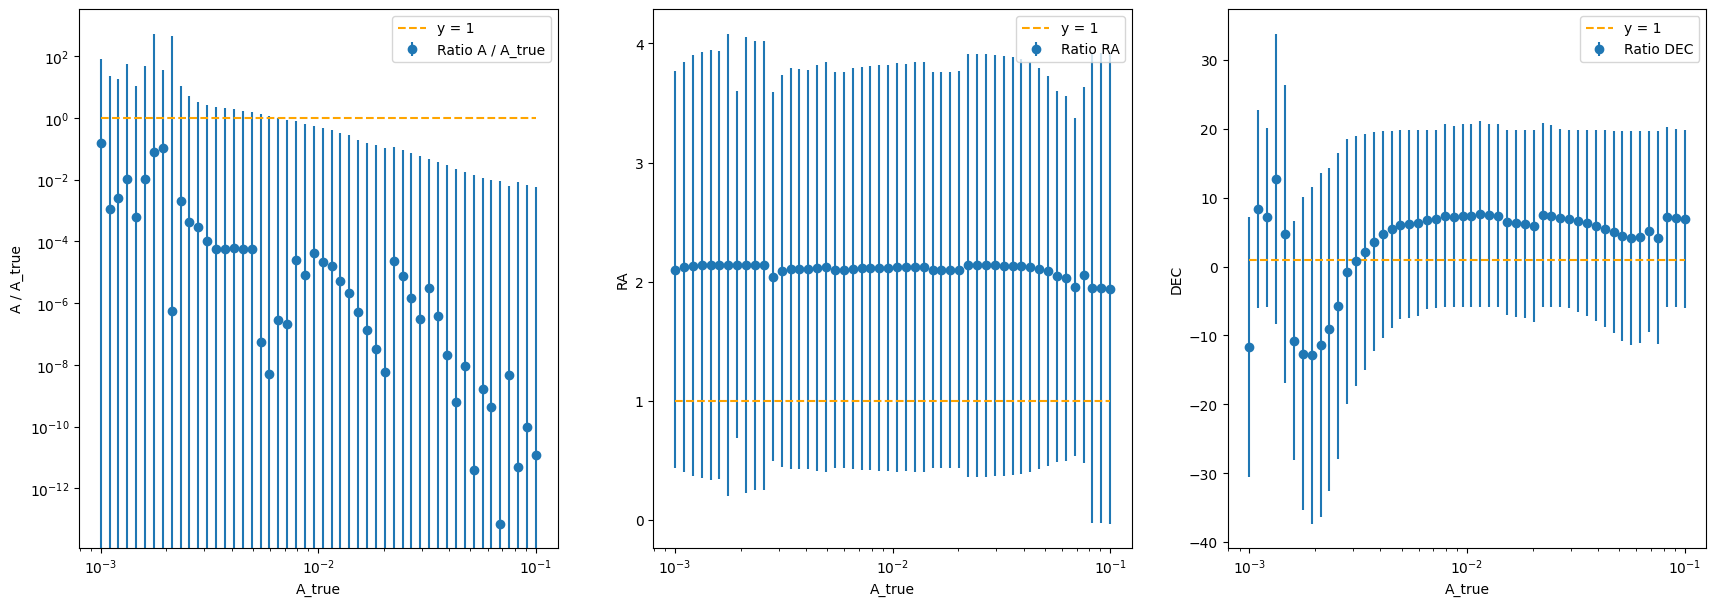

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered4_densMonopFixed, "A", "A", nsigma=1, figax=(fig, ax[0]), yscale='log', surface=False)
compareFit_ratio(dfMinuit_filtered4_densMonopFixed, "A", "ra", ylabel="RA", nsigma=5, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered4_densMonopFixed, "A", "dec", ylabel="DEC", nsigma=5, figax=(fig, ax[2]), surface=False)

sufix = "Cluster_A_study_ratioARaDec_NoMonop_PoissVar"
get_savefig(plt, output_path, sufix)

In [14]:
dfMinuit_filtered4_densMonop_notFixed = dfMinuit_data4_dens[~mask]
dfMinuit_filtered4_densMonop_notFixed

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,N*_true,A_true,ra_true,dec_true,Cluster_ID
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,int64,float64,int64,int64,str26
01KT3QFZZHN10T2CCQSN6K7FTS,0.9977435938260857,1.0,0.004505397555700286,False,0.0,inf,0.00028812848343090904,1.0,0.04526617162890327,False,0.0,1.0,336.7783558672512,100.0,250.82793077252148,False,0.0,360.0,86.04493981354206,0.0,162.1194804959273,False,-90.0,90.0,True,1,0.001,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QG7763SY4ZMZTHATS8R62,0.9977433765998709,1.0,0.004505395898273035,False,0.0,inf,0.00022153003885993288,1.0,0.05518884020942001,False,0.0,1.0,344.5262076952035,100.0,263.31207929783733,False,0.0,360.0,84.1861422853536,0.0,164.11280663443728,False,-90.0,90.0,True,1,0.0010985411419875584,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGBKCXCCVBVAX36NNF686,0.9977406708241074,1.0,0.004505398291366147,False,0.0,inf,0.0003258126807833808,1.0,0.04005582933675572,False,0.0,1.0,350.73821609518376,100.0,274.98280436537823,False,0.0,360.0,88.97821177377932,0.0,144.80238336567248,False,-90.0,90.0,True,1,0.0012067926406393288,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGHRQQ5ZW5VEPVZCFG2PB,0.9977066551406008,1.0,0.00450541068903948,False,0.0,inf,7.166339932604762e-06,1.0,0.21097346379648815,False,0.0,1.0,353.08784446592244,100.0,280.1790625242288,False,0.0,360.0,78.8251845530984,0.0,128.2015461704786,False,-90.0,90.0,True,1,0.0013257113655901094,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGQ0PT12SAX3GJ4S79HX6,0.9977414696381484,1.0,0.004505396854567023,False,0.0,inf,2.075821386949081e-06,1.0,0.026757462590006206,False,0.0,1.0,353.98476647224743,100.0,282.22837739718307,False,0.0,360.0,50.24364706532432,0.0,91.65319049120514,False,-90.0,90.0,True,1,0.0014563484775012444,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGXGGEK66KP2ZMDPYXEY8,0.997740894742537,1.0,0.004505398472942401,False,0.0,inf,6.003687992447656e-07,1.0,0.022219020119907163,False,0.0,1.0,353.23468922313776,100.0,280.44294025700316,False,0.0,360.0,45.542096153083925,0.0,93.03536862508821,False,-90.0,90.0,True,1,0.0015998587196060573,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QH1WMDJEKT52R139KRZEH,0.9977442555408268,1.0,0.0045053954904296645,False,0.0,inf,2.8767138544116084e-06,1.0,0.030341406443663906,False,0.0,1.0,355.19815804894876,100.0,285.28810007604187,False,0.0,360.0,60.46334319264686,0.0,102.57669283427002,False,-90.0,90.0,True,1,0.0017575106248547913,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QH6JGJMDVCB2S71H6F7FB,0.9977260626537086,1.0,0.00450540051478604,False,0.0,inf,4.807873137307528e-07,1.0,0.05517990288548157,False,0.0,1.0,356.6500776980928,100.0,289.3667114037584,False,0.0,360.0,73.55612657636853,0.0,118.52128670357655,False,-90.0,90.0,True,1,0.0019306977288832496,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QHBV0MJZE115V08RM5P1H,0.9977422277761748,1.0,0.004505394897674708,False,0.0,inf,0.0002656872544855039,1.0,0.04536501417917828,False,0.0,1.0,359.2259150254854,100.0,299.3236200814346,False,0.0,360.0,89.97147418742114,0.0,151.928229137825,False,-90.0,90.0,True,1,0.0021209508879201904,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K


Saving Cluster_A_study_ratioARaDec_withN1_PoissVar in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_ratioARaDec_withN1_PoissVar.pdf


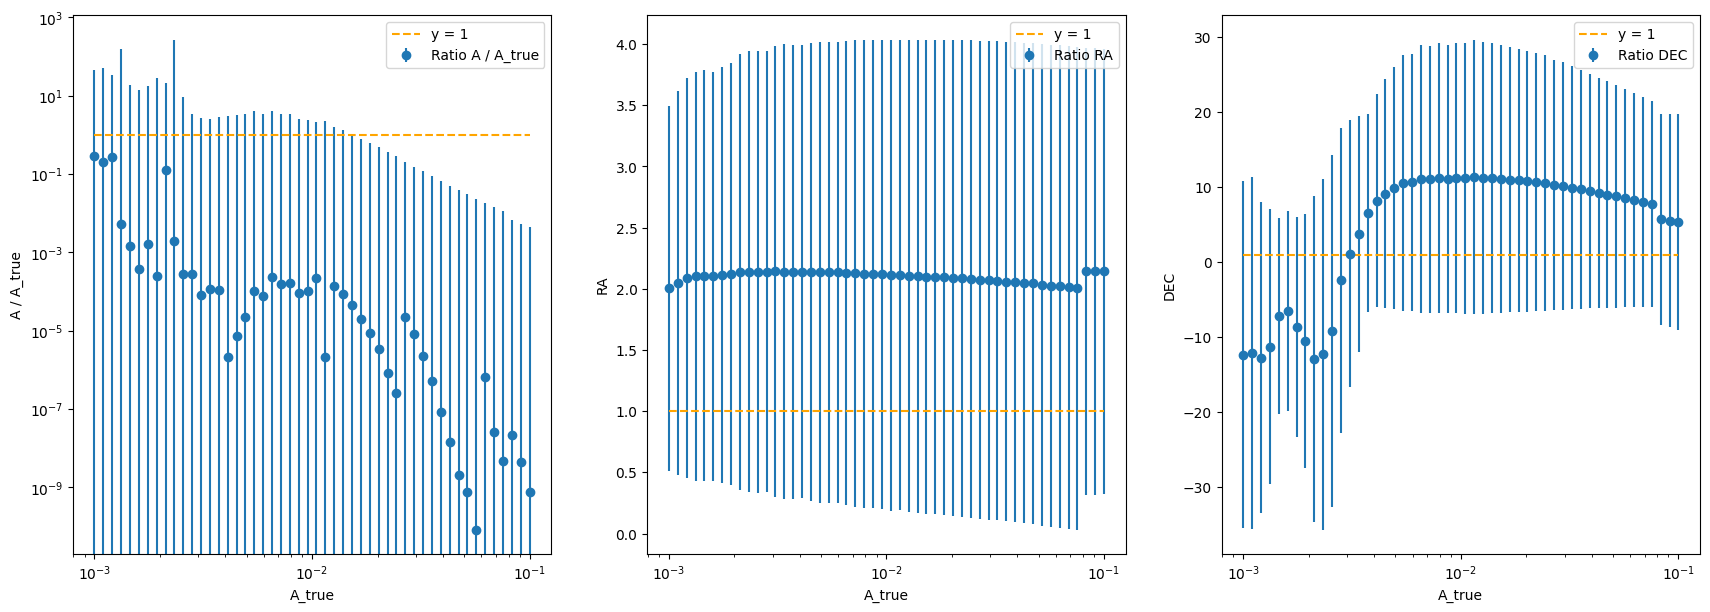

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered4_densMonop_notFixed, "A", "A", nsigma=1, figax=(fig, ax[0]), yscale='log', surface=False)
compareFit_ratio(dfMinuit_filtered4_densMonop_notFixed, "A", "ra", ylabel="RA", nsigma=5, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered4_densMonop_notFixed, "A", "dec", ylabel="DEC", nsigma=5, figax=(fig, ax[2]), surface=False)

sufix = "Cluster_A_study_ratioARaDec_withN1_PoissVar"
get_savefig(plt, output_path, sufix)

## Fitting the curves

In [ ]:
def get_term2(log_x, log_x0, alpha, beta, delta):
    x_over_x0 = 10**(log_x - log_x0)
    return (1.0 + x_over_x0**(1.0 / delta)) ** ((beta - alpha) * delta)
    

def smooth_broken_power_law_log(log_x, log_A, log_x0, alpha, beta, delta=0.5):
    """
    Modèle de Smooth Broken Power-Law adapté aux données en échelle log.
    
    Paramètres :
    ------------
    log_x  : array-like, le log10 de la variable indépendante (log10(A_true))
    log_A  : float, normalisation (en log10)
    log_x0 : float, position du coude (en log10(A_true)) -> C'est ce que vous cherchez !
    alpha  : float, pente asymptotique avant le coude (x << x0)
    beta   : float, pente asymptotique après le coude (x >> x0)
    delta  : float, paramètre de lissage (smoothness). 
             Plus delta est petit, plus la transition est douce.
    """
    x_over_x0 = 10**(log_x - log_x0)
    
    # Formule mathématique de la Smooth Broken Power-Law
    term1 = x_over_x0 ** alpha
    #term2 = get_term2(log_x, log_x0, alpha, beta, delta)
    term2 = (1.0 + x_over_x0**(1.0 / delta)) ** ((beta - alpha) * delta)
    
    log_y = log_A + np.log10(term1 * term2)
    return log_y


par = "dec"
diff = np.abs(dfMinuit_filtered[par] - dfMinuit_filtered[f"{par}_true"])
init = (-1, -1.2, -0.8, 0, -0.3)
x_fit = np.log10(dfMinuit_filtered["A_true"])
y_fit = np.log10(diff)
y_err = np.log10(dfMinuit_filtered[f"{par}_err"])
par_name = ('log_A', 'log_x0', 'alpha', 'beta', 'delta')
bounds = ([-np.inf, -2, -np.inf, -np.inf, -np.inf], [np.inf, -1, np.inf, np.inf, np.inf])
bounds = list(zip(bounds[0], bounds[1]))
bounds = None

m = fit_minuit(x_fit, y_fit, y_err, smooth_broken_power_law_log, init, par_name, bounds=bounds)

# y_plot = smooth_broken_power_law_log(x_fit, *m.values)
# plt.scatter(10**x_fit, 10**y_fit)
# plt.plot(10**x_fit, 10**y_plot, c='r')
# plt.xscale('log');


m

In [ ]:
10**m.values[1]

In [ ]:
y_plot = smooth_broken_power_law_log(x_fit, *m.values)
plt.scatter(10**x_fit, 10**y_fit)
plt.plot(10**x_fit, 10**y_plot, c='r')
plt.xscale('log')
#plt.plot(10**x_fit, 10**np.power((x_fit - m.values[1]), m.values[2]));
#plt.plot(10**x_fit, get_term2(x_fit, *m.values[1:]));

In [ ]:
def plot_fit_err(x_fit, y_fit, y_err, values, model, nsigma=, **kwargs):
    '''Plot on a same figure data and its fit, and return the corresponding fig, ax variables.
    
    Parameters:
    - x_fit, y_fit: original data used to compute the fit.
    - values: tuple containing the parameter values obtainds by the fit.
    - model: fitted function. The fit plot is obtained by: ax.plot(bins, model(x_fit, *values))

    Spetial keys for **kwargs:
     - title, xlabel, ylabel: allow to custom the figure.
     - figax: allow to use existing fig, ax variables, rather creating new ones; have to be tuple (fig, ax).
    '''
    if "figax" in kwargs.keys(): fig, ax = kwargs["figax"] #figax have to be tuple (fig, ax).
    else: fig, ax = plt.subplots()
    ax.scatter(x_fit, y_fit, label="data")
    ax.plot(x_fit, model(x_fit, *values), c="r", label="fit")
    y_inf = y_fit - y_err
    y_sup = y_fit + y_err
    ax.fill_between(x_fit, y_inf, y_sup, alpha=0.5, label=f"Error surface to {nsigma}$\sigma$")
    ax.legend()
    if "title" in kwargs.keys(): ax.set_title(kwargs["title"])
    if "xlabel" in kwargs.keys(): ax.set_xlabel(kwargs["xlabel"])
    if "ylabel" in kwargs.keys(): ax.set_xlabel(kwargs["ylabel"])

    #Saving figure:
    output_path = kwargs.get("output_path", False)
    if output_path:
        ext = kwargs.get('format', 'pdf')
        get_savefig(fig=fig, output_path=output_path, sufix="Fit", format=ext)
    return fig, ax

plot_fit_err(x_fit, y_fit, y_err, m.values, smooth_broken_power_law_log);

In [ ]:
def smooth_broken_power_law(x, A, x0, alpha, beta, delta=0.5):
    log_x, log_A, log_x0 = np.log10(x), np.log10(A), np.log10(x0)
    log_y = smooth_broken_power_law_log(log_x, log_A, log_x0, alpha, beta, delta)
    return 10**log_y


par = "ra"
diff = np.abs(dfMinuit_filtered[par] - dfMinuit_filtered[f"{par}_true"])
init = (1e-10, 6e-2, -0.8, 0, -0.3)
x_fit = dfMinuit_filtered["A_true"].copy()
y_fit = diff
y_err = dfMinuit_filtered[f"{par}_err"].copy()
par_name = ('A', 'x0', 'alpha', 'beta', 'delta')
bounds=([0, 0, -90], [1, 360, 90])

m = fit_minuit(x_fit, y_fit, y_err, smooth_broken_power_law, init, par_name)
m

In [ ]:
1e-10

In [ ]:
from lumMag_sampling import proba_schechter_lumRatio

def shchect_log(log_x, log_A, log_x0, alpha, phi_star):
    return proba_schechter_lumRatio(log_x/log_x, alpha, phi_star)


par = "dec"
diff = np.abs(dfMinuit_filtered[par] - dfMinuit_filtered[f"{par}_true"])
init = (-1, -1.2, -1, 0)
x_fit = np.log10(dfMinuit_filtered["A_true"])
y_fit = np.log10(diff)
y_err = np.log10(dfMinuit_filtered[f"{par}_err"])
par_name = ('log_A', 'log_x0', 'alpha', 'phi_star')
bounds = ([-np.inf, -2, -np.inf, -np.inf], [np.inf, -1, np.inf, np.inf])
bounds = list(zip(bounds[0], bounds[1]))
bounds = None

m = fit_minuit(x_fit, y_fit, y_err, shchect_log, init, par_name, bounds=bounds)

# y_plot = smooth_broken_power_law_log(x_fit, *m.values)
# plt.scatter(10**x_fit, 10**y_fit)
# plt.plot(10**x_fit, 10**y_plot, c='r')
# plt.xscale('log');


m